In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Zadanie 1

In [2]:
x0 = 1.0
machine_epsilon = np.finfo(float).eps
k = np.arange(17)
h = 10.0**(-k)

In [32]:
f_x0 = np.tan(x0)
exact_derivative = 1.0 + f_x0**2
exact_second_derivative = 2.0 * f_x0 * exact_derivative
exact_third_derivative = 6* f_x0**4 + 8* f_x0**2 + 2

#### Wartość pochodniej w prost

In [33]:
approx_derivative = (np.tan(x0 + h) - f_x0) / h

In [34]:
error_computational = np.abs(approx_derivative - exact_derivative)
error_method = (np.abs(exact_second_derivative) / 2.0) * h
error_numerical = (2.0 * machine_epsilon * np.abs(f_x0)) / h

In [35]:
h_min_empirical = h[np.argmin(error_computational)]
h_min_theoretical = 2.0 * np.sqrt(machine_epsilon / np.abs(exact_second_derivative))

#### Wartość pochodnej ze wzoru roznic centralnych

In [54]:
approx_central_derivative = (np.tan(x0 + h) - np.tan(x0 - h)) / (2.0 * h)

In [55]:
central_error_computational = np.abs(approx_central_derivative - exact_derivative)
central_error_method = (np.abs(exact_third_derivative) / 6.0) * h**2
central_error_numerical = (machine_epsilon * np.abs(f_x0)) / h

In [56]:
central_h_min_empirical = h[np.argmin(central_error_computational)]
central_h_min_theoretical = np.cbrt(3.0 * machine_epsilon / np.abs(exact_third_derivative))

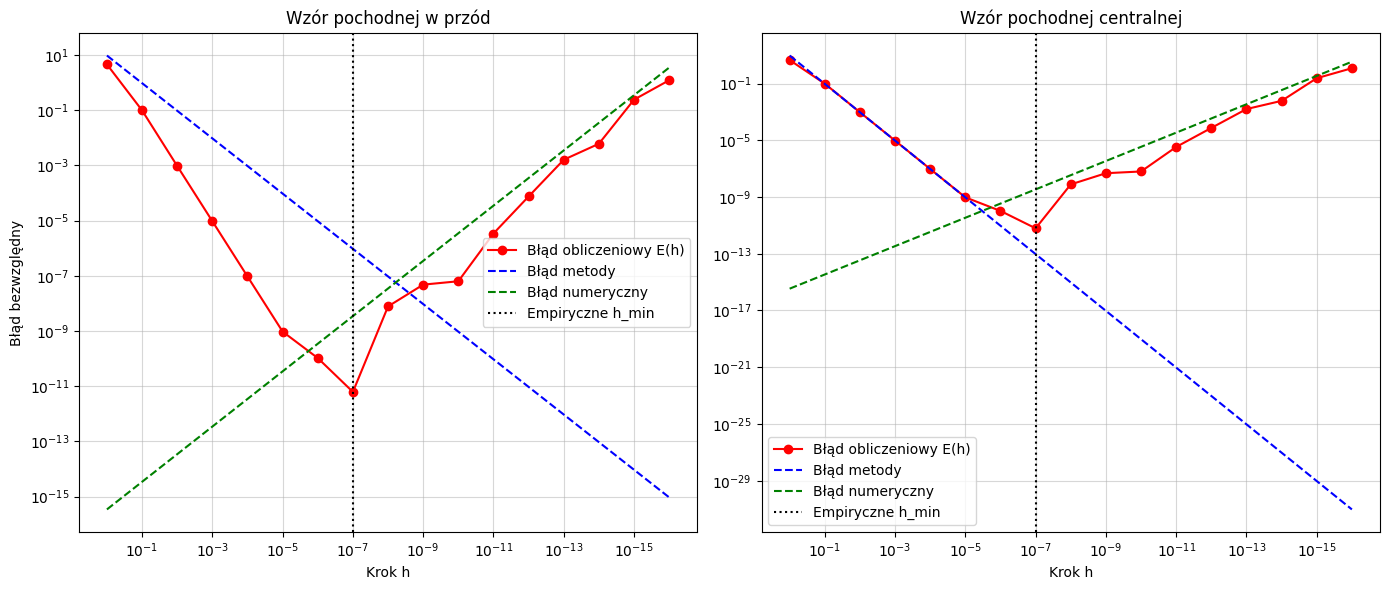

In [57]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# --- Wykres 1: Różnica w przód ---
axs[0].loglog(h, error_computational, 'ro-', label='Błąd obliczeniowy E(h)')
axs[0].loglog(h, error_method, 'b--', label='Błąd metody')
axs[0].loglog(h, error_numerical, 'g--', label='Błąd numeryczny')
axs[0].axvline(h_min_empirical, color='k', linestyle=':', label='Empiryczne h_min')

axs[0].set_xlabel('Krok h')
axs[0].set_ylabel('Błąd bezwzględny')
axs[0].set_title('Wzór pochodnej w przód')
axs[0].grid(True, which="both", ls="-", alpha=0.5)
axs[0].legend()
axs[0].invert_xaxis()

# --- Wykres 2: Różnica centralna ---
axs[1].loglog(h, central_error_computational, 'ro-', label='Błąd obliczeniowy E(h)')
axs[1].loglog(h, central_error_method, 'b--', label='Błąd metody')
axs[1].loglog(h, central_error_numerical, 'g--', label='Błąd numeryczny')
axs[1].axvline(central_h_min_empirical, color='k', linestyle=':', label='Empiryczne h_min')

axs[1].set_xlabel('Krok h')
axs[1].set_title('Wzór pochodnej centralnej')
axs[1].grid(True, which="both", ls="-", alpha=0.5)
axs[1].legend()
axs[1].invert_xaxis()

plt.tight_layout()
plt.show()